## Wczytanie bibliotek

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestRegressor

# Przygotowanie zbioru danych do eksploracji

In [2]:
df = pd.read_csv("VLagun_PhysChem_Years4.csv")
X = df.iloc[:, 0:19]
y = df.iloc[:, 19]
features_names = df.columns
print(y)

0      0
1      0
2      0
3      0
4      0
      ..
115    1
116    1
117    1
118    1
119    1
Name: Years, Length: 120, dtype: int64


### Kształt zbioru danych

In [3]:
print('feature Shape:', df.shape)

feature Shape: (120, 20)


## Wprowadzenie Rnadom Forest
### Wypisanie ważności cech

In [4]:
model = RandomForestRegressor(n_estimators=100, random_state=42)

model.fit(X, y)

importances = model.feature_importances_

for feature, importance in zip(X.columns, importances):
    np.argsort(importance)
    print(feature, importance)

PSU 0.03190507394162355
O2 0.003582589419099777
temp. 0.07790081454922056
SS 0.08060777055841534
SRP 0.004036798831773258
DOP 0.013983324598623103
PP 0.014702188288849297
NH4N 0.005806634578773869
NO3N 0.008764932070171663
DON 0.007685484481212123
PN 0.014872554391167641
TN/TP 0.014456222928889026
Fe 0.011077016096328418
SiO4Si 0.06806378115215292
DOC 0.21533693442451995
TPOC 0.03414537362623922
Windspeedinsitu 0.3691279556268485
Depth 0.008510685985174741
DINtoDIP 0.01543386445091692


## Posortowanie ważności cech

In [17]:
importances_list = list(importances)

# List of tuples with variable and importance
feature_importances = [(feature, round(importance,3)) for feature, importance in zip(X, importances)]

# Sort the feature importances by most important first
feature_importances = sorted(feature_importances, key=lambda x: x[1], reverse=True)

# Print out the feature and importances
[print('Variable: {:17} Importance: {}'.format(*pair)) for pair in feature_importances];


Variable: Windspeedinsitu   Importance: 0.369
Variable: DOC               Importance: 0.215
Variable: SS                Importance: 0.081
Variable: temp.             Importance: 0.078
Variable: SiO4Si            Importance: 0.068
Variable: TPOC              Importance: 0.034
Variable: PSU               Importance: 0.032
Variable: PP                Importance: 0.015
Variable: PN                Importance: 0.015
Variable: DINtoDIP          Importance: 0.015
Variable: DOP               Importance: 0.014
Variable: TN/TP             Importance: 0.014
Variable: Fe                Importance: 0.011
Variable: NO3N              Importance: 0.009
Variable: Depth             Importance: 0.009
Variable: DON               Importance: 0.008
Variable: NH4N              Importance: 0.006
Variable: O2                Importance: 0.004
Variable: SRP               Importance: 0.004


## Wizualizacja posortowanych ważności cech

In [6]:
import seaborn as sns
from sklearn import model_selection
from sklearn import preprocessing
from sklearn import ensemble, tree, metrics

In [7]:
estimator_rf = RandomForestRegressor(
    n_jobs=-1,
    n_estimators=100,
    random_state=42
)
estimator_rf.fit(X,y)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [8]:
feature_importance_df = pd.DataFrame(estimator_rf.feature_importances_, index=X.columns.values, columns=["Importance"])
feature_importance_df.head()

,Importance
PSU,0.031905
O2,0.003583
temp.,0.077901
SS,0.080608
SRP,0.004037


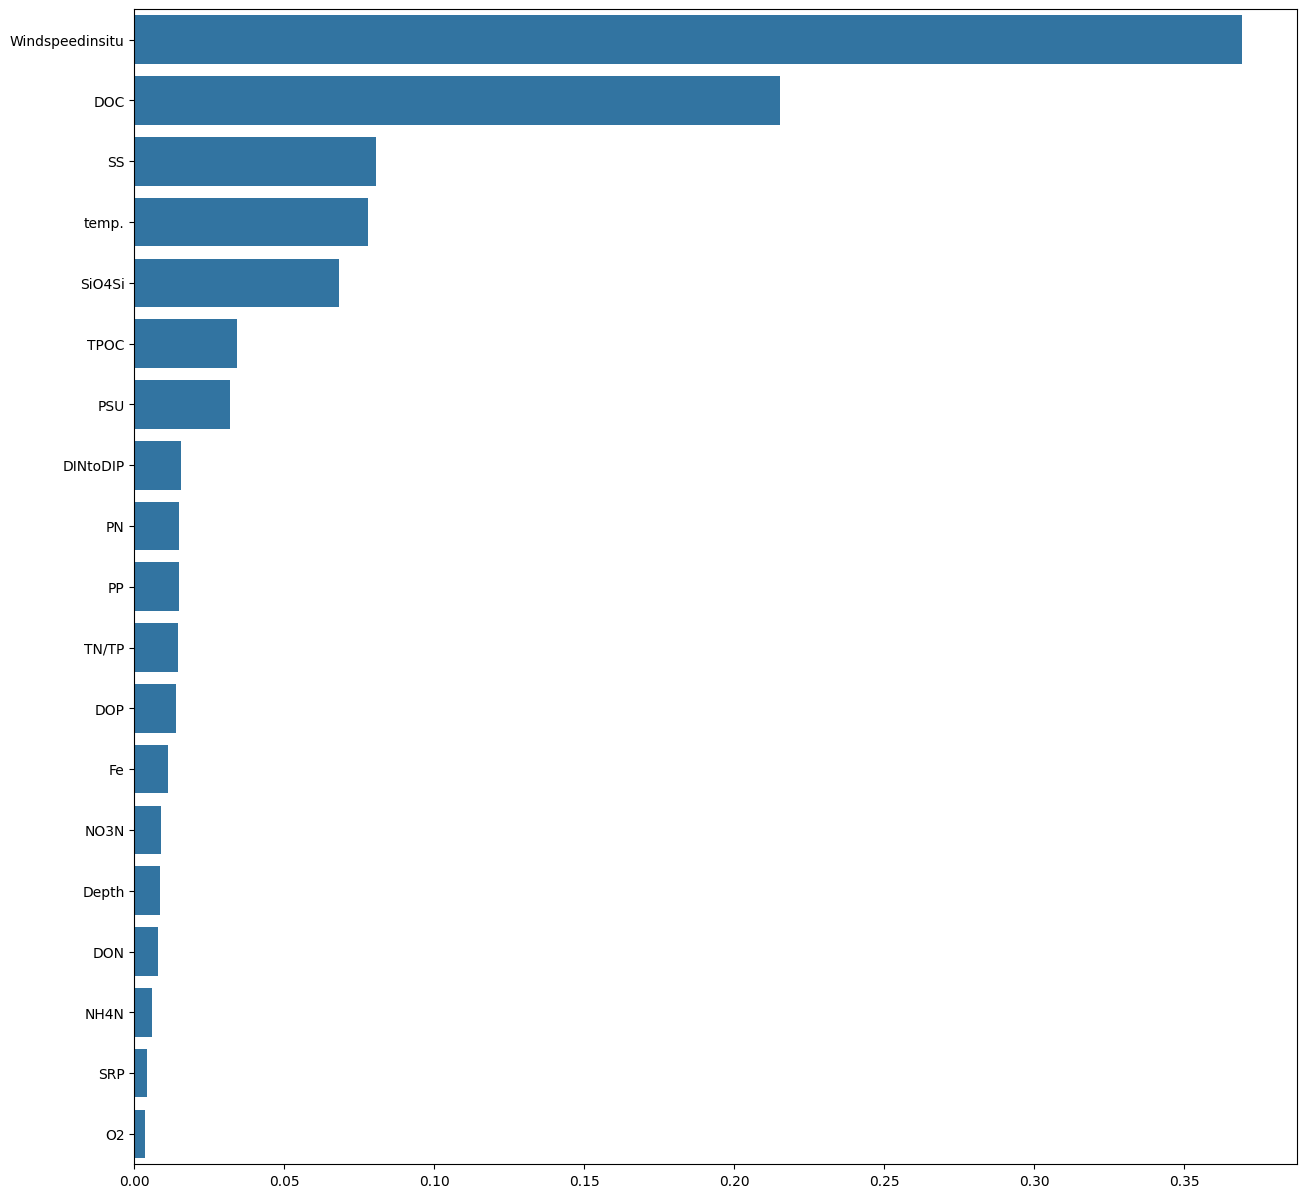

In [32]:
feature_importance_df.sort_values(by='Importance', inplace=True, ascending=False)
plt.figure(figsize=(15, 15))
sns.barplot(data=feature_importance_df,
            x=feature_importance_df.values.flatten(),
            y=feature_importance_df.index.values)

plt.show()